In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc_context
import matplotlib.patheffects as path_effects
import sunpy
import sunpy.map
from sunpy.coordinates import propagate_with_solar_surface
import astropy
from astropy.coordinates import SkyCoord
import astropy.units as u
import astropy.constants as const
from astropy.io import fits, ascii
from astropy.time import Time
from astropy.convolution import convolve, Gaussian2DKernel
from astropy.wcs import WCS
from astropy.visualization import ImageNormalize, AsinhStretch
from streamtracer import StreamTracer, VectorGrid
from extrapolater import PotentialField
from helpers import from_local

import h5py 
import dask.array as da 
from ndcube import NDCube

In [14]:
file_Hbeta_pr = h5py.File("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_pr.hdf5")
Hbeta_pr_set = file_Hbeta_pr["vbi_img"]
Hbeta_pr_da = da.from_array(Hbeta_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Hbeta_date_obs = Time(ascii.read("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_date_avg.txt")["DATE-AVG"])

In [3]:
dkist_vbi_target_header = fits.getheader("../../data/pid_1_123_aux/plot_ready/dkist_target_wcs_header_before_crop.fits",
                                        ignore_missing_simple=True)

dkist_vbi_target_data = np.zeros((4096,4096))

dkist_vbi_target_cube = NDCube(dkist_vbi_target_data,WCS(dkist_vbi_target_header, naxis=2))
dkist_vbi_target_cube_crop = dkist_vbi_target_cube[128:-128,128:-128]
dkist_vbi_target_cube_crop_rebin = dkist_vbi_target_cube_crop.rebin((8,8))

Set MJD-BEG to 59876.791095 from DATE-BEG.
Set MJD-AVG to 59876.791095 from DATE-AVG.
Set MJD-END to 59876.791095 from DATE-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [4]:
sotsp_potential_field_array = np.load("/cluster/home/zhuyin/work/extrapolation/sotsp_20221024_184138/sotsp_potential_extrapolated_20221024_184138.npy")

In [7]:
sotsp_map = sunpy.map.Map("/cluster/home/zhuyin/Solar/extrapolate_schmidt64/data/sotsp_br_warp_to_hmi.fits")
sotsp_map = sotsp_map.submap([16,16]*u.pix, top_right=[959-16, 511 - 16]*u.pix)
sotsp_map.meta["bunit"] = "Gauss"

sotsp_potential_ex = PotentialField(magnetogram=sotsp_map, width_z=100e5*128*u.cm, shape_z=128*u.pixel)
sotsp_potential_bottom_boundary = sotsp_potential_ex.project_boundary(sotsp_potential_ex.range.x, sotsp_potential_ex.range.y).value

In [20]:
sotsp_potential_field_grid_spacing = np.array([sotsp_potential_ex.delta.x.to_value(u.Mm/u.pix),
                                sotsp_potential_ex.delta.y.to_value(u.Mm/u.pix),
                                sotsp_potential_ex.delta.z.to_value(u.Mm/u.pix)])

sotsp_potential_field_grid = VectorGrid(sotsp_potential_field_array, sotsp_potential_field_grid_spacing,
                                        origin_coord=[sotsp_potential_ex.range.x[0].to_value(u.Mm),
                                                      sotsp_potential_ex.range.y[0].to_value(u.Mm),
                                                      sotsp_potential_ex.range.z[0].to_value(u.Mm)])

In [30]:
seeds = np.array([[ii, jj, 0] for ii in np.linspace(420, 600, 40)*sotsp_potential_ex.delta.x.to_value(u.Mm/u.pix) + sotsp_potential_ex.range.x[0].to_value(u.Mm) \
                    for jj in np.linspace(200, 380, 40)*sotsp_potential_ex.delta.y.to_value(u.Mm/u.pix) + sotsp_potential_ex.range.y[0].to_value(u.Mm)])

nsteps = 10000
step_size = 0.1
tracer = StreamTracer(nsteps, step_size)
tracer.trace(seeds, sotsp_potential_field_grid)

In [31]:
fline_heeq = []
for fline in tracer.xs[:]:
    fline_heeq.append(from_local(fline[:,0]*u.Mm, fline[:,1]*u.Mm, fline[:,2]*u.Mm, sotsp_potential_ex.magnetogram.center))

(-0.5, 3839.5, -0.5, 3839.5)

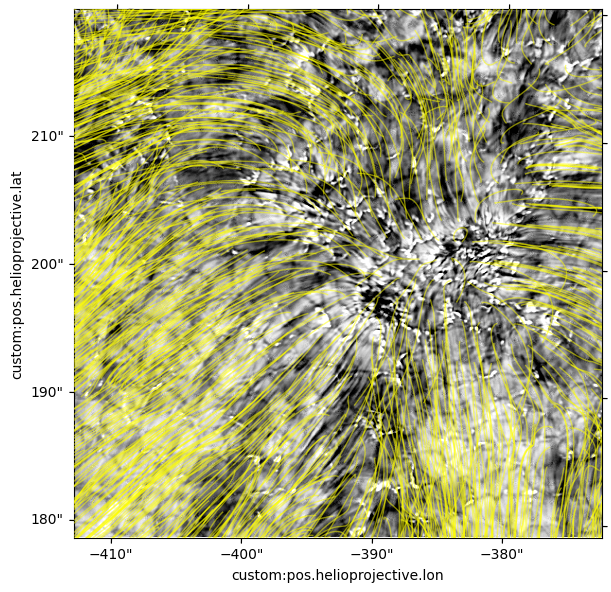

In [34]:
fig = plt.figure(figsize=(6,6), layout="constrained")

ax = fig.add_subplot(111, projection=dkist_vbi_target_cube_crop.wcs)
ax.imshow(Hbeta_pr_da[100,:,:], origin="lower", cmap="Greys_r",
          norm=ImageNormalize(vmin=0,vmax=1),
          interpolation="none")

ax_lim = ax.axis()

with propagate_with_solar_surface():
    for fline in fline_heeq[:]:
        # ax.plot_coord(fline[0], color="red", alpha=0.3, lw=2, marker="o")
        ax.plot_coord(fline, color="#FFFF00", alpha=0.5, lw=1)

ax.axis(ax_lim)

(-0.5, 3839.5, -0.5, 3839.5)

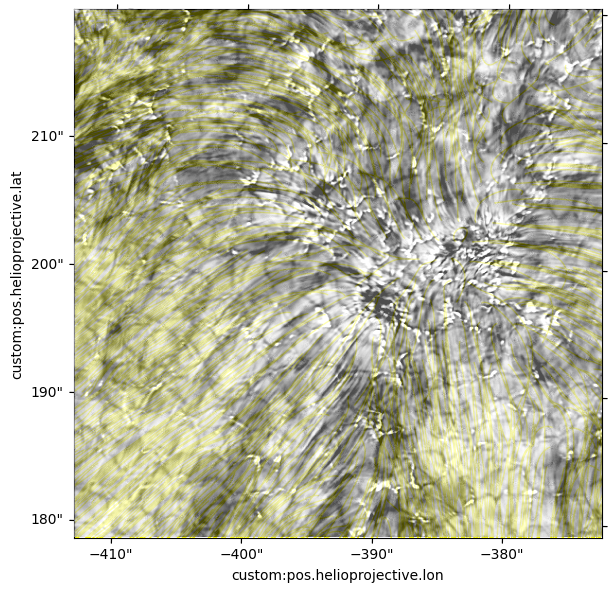

In [39]:
fig = plt.figure(figsize=(6,6), layout="constrained")

ax = fig.add_subplot(111, projection=dkist_vbi_target_cube_crop.wcs)
ax.imshow(Hbeta_pr_da[100,:,:], origin="lower", cmap="Greys_r",
          norm=ImageNormalize(vmin=0,vmax=1),
          interpolation="none", alpha=0.7, zorder=3)

ax_lim = ax.axis()

with propagate_with_solar_surface():
    for fline in fline_heeq[:]:
        # ax.plot_coord(fline[0], color="red", alpha=0.3, lw=2, marker="o")
        ax.plot_coord(fline, color="#FFFF00", alpha=1, lw=1, zorder=0)

ax.axis(ax_lim)

(-0.5, 3839.5, -0.5, 3839.5)

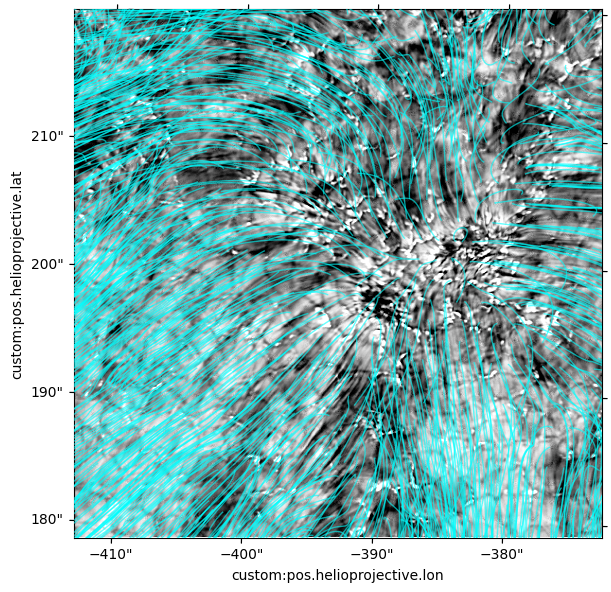

In [38]:
fig = plt.figure(figsize=(6,6), layout="constrained")

ax = fig.add_subplot(111, projection=dkist_vbi_target_cube_crop.wcs)
ax.imshow(Hbeta_pr_da[100,:,:], origin="lower", cmap="Greys_r",
          norm=ImageNormalize(vmin=0,vmax=1),
          interpolation="none")

ax_lim = ax.axis()

with propagate_with_solar_surface():
    for fline in fline_heeq[:]:
        # ax.plot_coord(fline[0], color="red", alpha=0.3, lw=2, marker="o")
        ax.plot_coord(fline, color="#00FFFF", alpha=0.6, lw=1)

ax.axis(ax_lim)